In [4]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1

mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0

# Replace df.append with pd.concat
df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40, ignore_index=True)

In [5]:
df.head()

,feature1,feature2,feature3,target
0,-0.367548,-1.137460,-1.322148,1
1,0.177061,-0.598109,1.226512,0
2,0.420623,0.411620,-0.071324,1
3,1.968435,-0.547788,-0.679418,1
4,-2.506230,0.146960,0.606195,1


In [7]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [8]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [9]:

# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [10]:

# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
     

In [11]:

eigen_values
     

array([1.3536065 , 0.94557084, 0.77774573])

In [12]:

eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

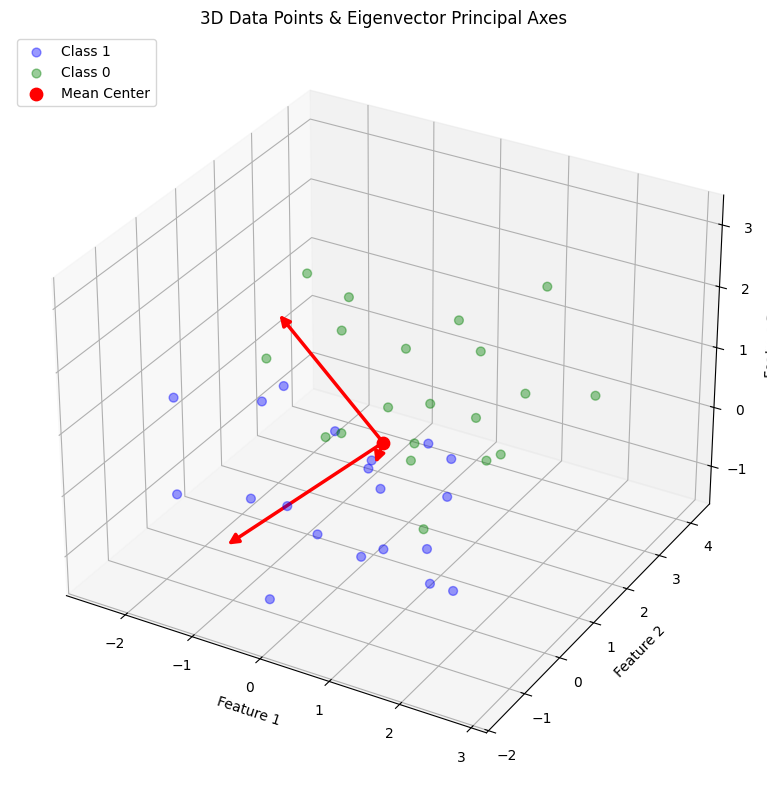

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# ---------------------------------------------------------
# 1. Modern 3D Arrow Class (Compatible with Matplotlib 3.5+)
# ---------------------------------------------------------
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

# ---------------------------------------------------------
# 2. Data Generation
# ---------------------------------------------------------
np.random.seed(23)

# Class 1
mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)
df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1

# Class 2
mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)
df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0

# Concatenate & Shuffle
df = pd.concat([df, df1], ignore_index=True)
df = df.sample(40, random_state=23, ignore_index=True)

# ---------------------------------------------------------
# 3. Compute Covariance Matrix & Eigenvectors
# ---------------------------------------------------------
features = df[['feature1', 'feature2', 'feature3']].values
cov_matrix = np.cov(features, rowvar=False)
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# ---------------------------------------------------------
# 4. 3D Plotting
# ---------------------------------------------------------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter points: Class 1 and Class 0
class_1 = df[df['target'] == 1]
class_0 = df[df['target'] == 0]

ax.scatter(class_1['feature1'], class_1['feature2'], class_1['feature3'], 
           s=40, color='blue', alpha=0.4, label='Class 1')
ax.scatter(class_0['feature1'], class_0['feature2'], class_0['feature3'], 
           s=40, color='green', alpha=0.4, label='Class 0')

# Mean point
mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()
ax.scatter([mean_x], [mean_y], [mean_z], s=80, color='red', marker='o', label='Mean Center')

# Draw Eigenvectors scaled by standard deviation (sqrt of eigenvalues)
for i in range(len(eigen_values)):
    scale = np.sqrt(eigen_values[i]) * 2  # Scaled by 2 standard deviations
    v = eigen_vectors[:, i] * scale

    arrow = Arrow3D(
        [mean_x, mean_x + v[0]],
        [mean_y, mean_y + v[1]],
        [mean_z, mean_z + v[2]],
        mutation_scale=15,
        lw=2.5,
        arrowstyle="-|>",
        color="red"
    )
    ax.add_artist(arrow)

# Axis labels & view
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('3D Data Points & Eigenvector Principal Axes')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [15]:
pc = eigen_vectors[0:2]
pc

array([[ 0.3853039 , -0.69239396, -0.61002583],
       [-0.84174906,  0.00718615, -0.53982115]])

In [16]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.624805,-0.066803,1
1,-2.026310,-2.096616,0
2,0.835537,-0.136236,1
3,-2.204154,-1.337913,0
4,-0.290545,-3.802688,0


In [17]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()